# **Install dependencies**

In [1]:
# !pip install torch torchvision torchaudio --quiet
# !pip install transformers diffusers accelerate timm einops --quiet


# **Mount Drive and Extract Dataset**

In [2]:
# from google.colab import drive
# import zipfile
import os

# Mount Google Drive
# drive.mount('/content/drive')

# Path to your zip file
# zip_path = "/content/drive/MyDrive/VTR-Diffusion/zalando-hd-resized.zip"
extract_path = "/users/9/chand968/dataset"

# Unzip dataset if not already unzipped
# if not os.path.exists(extract_path):
#     with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#         zip_ref.extractall(extract_path)

print("Dataset extracted at:", extract_path)


Dataset extracted at: /users/9/chand968/dataset


In [3]:
# import sys
# print(sys.executable)


In [4]:
# !pip install transformers

# **Dataset Loader (VITON-HD compatible)**

In [5]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os

class VITONHDDataset(Dataset):
    def __init__(self, root_dir, pair_txt="train_pairs.txt", transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.pair_file = os.path.join(root_dir, pair_txt)

        with open(self.pair_file, "r") as f:
            self.pairs = [line.strip().split() for line in f.readlines()]

        self.image_dir = os.path.join(root_dir, "train", "image")
        self.cloth_dir = os.path.join(root_dir, "train", "cloth")

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        person_img_name, cloth_img_name = self.pairs[idx]
        person = Image.open(os.path.join(self.image_dir, person_img_name)).convert("RGB")
        cloth = Image.open(os.path.join(self.cloth_dir, cloth_img_name)).convert("RGB")

        if self.transform:
            person = self.transform(person)
            cloth = self.transform(cloth)

        prompt = f"Change the color of the clothes in {cloth_img_name} to red"

        return {"image": person, "cloth": cloth, "prompt": prompt}

transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

dataset = VITONHDDataset(extract_path, "train_pairs.txt", transform=transform)
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)


In [6]:
# !conda install -c conda-forge transformers -y
# !{sys.executable} -m pip install --upgrade pip
# !{sys.executable} -m pip install transformers


# **CLIP Text Embeddings**

In [7]:
from transformers import CLIPTextModel, CLIPTokenizer

tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")
text_encoder = CLIPTextModel.from_pretrained("openai/clip-vit-base-patch32").cuda()

def get_text_embedding(prompts):
    inputs = tokenizer(prompts, padding="max_length", max_length=16,
                       truncation=True, return_tensors="pt").to("cuda")
    with torch.no_grad():
        embeddings = text_encoder(**inputs).last_hidden_state
    return embeddings


/users/9/chand968/py310_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# **Text-Conditioned UNet**

In [8]:
import torch.nn as nn
import torch.nn.functional as F

class TextConditionedUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, hidden_dim=64, text_dim=512):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, hidden_dim, 3, padding=1)
        self.conv2 = nn.Conv2d(hidden_dim, hidden_dim, 3, padding=1)
        self.conv3 = nn.Conv2d(hidden_dim, out_channels, 3, padding=1)
        self.text_fc = nn.Linear(text_dim, hidden_dim)

    def forward(self, x, text_emb):
        B, _, H, W = x.shape
        text_proj = self.text_fc(text_emb[:, 0, :]).unsqueeze(-1).unsqueeze(-1).repeat(1,1,H,W)
        x = F.relu(self.conv1(x) + text_proj)
        x = F.relu(self.conv2(x))
        x = self.conv3(x)
        return x


# **Diffusion Utilities**

In [9]:
import torch
import numpy as np

def linear_beta_schedule(timesteps):
    beta_start, beta_end = 0.0001, 0.02
    return torch.linspace(beta_start, beta_end, timesteps)

class Diffusion:
    def __init__(self, model, timesteps=25):
        self.model = model
        self.timesteps = timesteps
        self.betas = linear_beta_schedule(timesteps).cuda()
        self.alphas = 1.0 - self.betas
        self.alpha_hat = torch.cumprod(self.alphas, dim=0)

    def add_noise(self, x0, t):
        noise = torch.randn_like(x0)
        alpha_hat_t = self.alpha_hat[t].view(-1,1,1,1)
        x_noisy = torch.sqrt(alpha_hat_t)*x0 + torch.sqrt(1-alpha_hat_t)*noise
        return x_noisy, noise

    def sample(self, shape, text_emb):
        x = torch.randn(shape).cuda()
        for t in reversed(range(self.timesteps)):
            pred_noise = self.model(x, text_emb)
            alpha = self.alphas[t]
            alpha_hat = self.alpha_hat[t]
            beta = self.betas[t]
            x = (1/torch.sqrt(alpha)) * (x - ((1-alpha)/torch.sqrt(1-alpha_hat)) * pred_noise)
            if t > 0:
                x += torch.sqrt(beta) * torch.randn_like(x)
        return x


# **Training Loop**

In [10]:
!nvidia-smi


Sun Dec  7 19:35:46 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A40                     On  |   00000000:0B:00.0 Off |                    0 |
|  0%   48C    P0             49W /  300W |     519MiB /  46068MiB |      3%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [13]:
import torch.nn.functional as F
from torch.cuda.amp import autocast, GradScaler

device = "cuda"
model = TextConditionedUNet().to(device)
diffusion = Diffusion(model, timesteps=25)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scaler = GradScaler()

epochs = 50
for epoch in range(epochs):
    for batch in dataloader:
        imgs = batch["cloth"].to(device)
        prompts = batch["prompt"]
        text_emb = get_text_embedding(prompts)

        t = torch.randint(0, diffusion.timesteps, (imgs.shape[0],), device=device).long()

        optimizer.zero_grad()
        with autocast():
            noisy_imgs, noise = diffusion.add_noise(imgs, t)
            pred_noise = model(noisy_imgs, text_emb)
            loss = F.mse_loss(pred_noise, noise)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

    print(f"Epoch {epoch} | Loss: {loss.item():.6f}")

/tmp/ipykernel_2969475/1346298663.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_2969475/1346298663.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 0 | Loss: 0.158103
Epoch 1 | Loss: 0.077283
Epoch 2 | Loss: 0.057559
Epoch 3 | Loss: 0.036432
Epoch 4 | Loss: 0.076816
Epoch 5 | Loss: 0.114411
Epoch 6 | Loss: 0.054302
Epoch 7 | Loss: 0.101526
Epoch 8 | Loss: 0.117324
Epoch 9 | Loss: 0.049047
Epoch 10 | Loss: 0.055021
Epoch 11 | Loss: 0.055130
Epoch 12 | Loss: 0.082785
Epoch 13 | Loss: 0.071207
Epoch 14 | Loss: 0.037414
Epoch 15 | Loss: 0.085997
Epoch 16 | Loss: 0.034672
Epoch 17 | Loss: 0.640761
Epoch 18 | Loss: 0.732655
Epoch 19 | Loss: 0.067082
Epoch 20 | Loss: 0.083317
Epoch 21 | Loss: 0.629129
Epoch 22 | Loss: 0.039189
Epoch 23 | Loss: 0.079346
Epoch 24 | Loss: 0.098629
Epoch 25 | Loss: 0.339531
Epoch 26 | Loss: 0.070202
Epoch 27 | Loss: 0.094300
Epoch 28 | Loss: 0.080555
Epoch 29 | Loss: 0.047191
Epoch 30 | Loss: 0.074395
Epoch 31 | Loss: 0.044811
Epoch 32 | Loss: 0.062512
Epoch 33 | Loss: 0.056419
Epoch 34 | Loss: 0.066732
Epoch 35 | Loss: 0.048992
Epoch 36 | Loss: 0.052014
Epoch 37 | Loss: 0.067074
Epoch 38 | Loss: 0.059

# **Sampling Images**

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0351107..1.7315089].


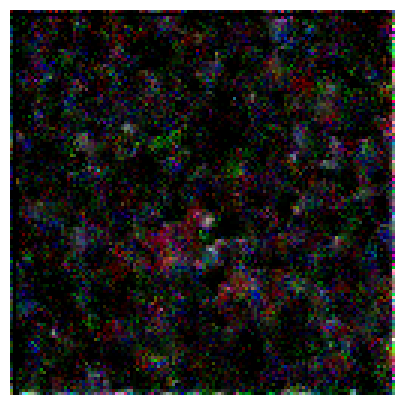

In [14]:
import torchvision
import matplotlib.pyplot as plt

sample_prompts = ["Change the shirt color to red"]
text_emb = get_text_embedding(sample_prompts)
sampled = diffusion.sample((1,3,128,128), text_emb)

# Detach the tensor before sending to matplotlib
grid = torchvision.utils.make_grid(sampled.detach().cpu(), nrow=1)

plt.figure(figsize=(5,5))
plt.imshow(grid.permute(1,2,0))
plt.axis('off')
plt.show()
